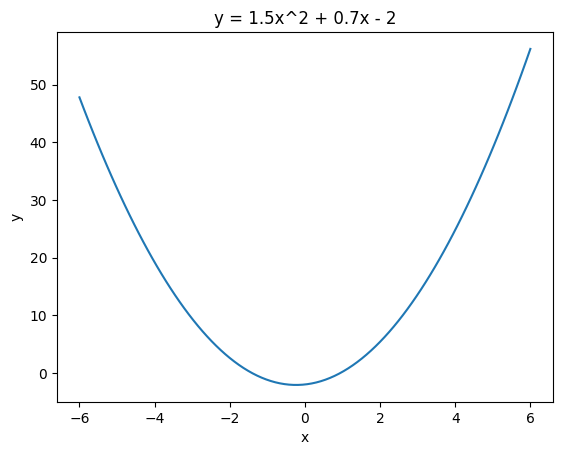

In [73]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # For reproducibility

# Set y = 1.5x^2 + 0.7x - 2
def f(x):
    return 1.5 * x**2 + 0.7 * x - 2

# Generate 100 uniformly spaced x values from -6 to 6
x = np.linspace(-6, 6, 100)

# Calculate corresponding y values using the function f
y = f(x)

# Plot the function
plt.plot(x, y)
plt.title('y = 1.5x^2 + 0.7x - 2')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

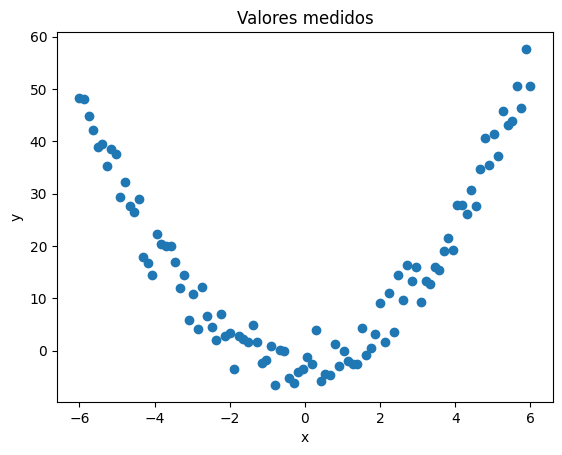

In [74]:
# Add noise to the y values
noise_amp = 0.1 * np.max(np.abs(y))
noise = np.random.uniform(-noise_amp, noise_amp, size=y.shape)
y_measured = y + noise

# Plot the noisy measurements
plt.scatter(x, y_measured)
plt.title('Valores medidos')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

A equação de regressão é $y = \theta_2x^2 + \theta_1x + \theta_0$.

A matriz de regressores é

$A =$
\begin{bmatrix}
x_1^2 & x_1 & 1 \\
x_2^2 & x_2 & 1 \\
\vdots & \vdots & \vdots \\
x_N^2 & x_N & 1
\end{bmatrix}

In [75]:
# Construct the design matrix for quadratic fitting
A = np.vstack([x**2, x, np.ones(len(x))]).T

# Perform least squares fitting to find coefficients
theta, _, _, _ = np.linalg.lstsq(A, y_measured)

# Display the fitted coefficients
print('Coeficientes estimados:')
for i in range(len(theta)):
    print(f'θ_{i} = {theta[i]:.2f}')

Coeficientes estimados:
θ_0 = 1.52
θ_1 = 0.47
θ_2 = -2.59


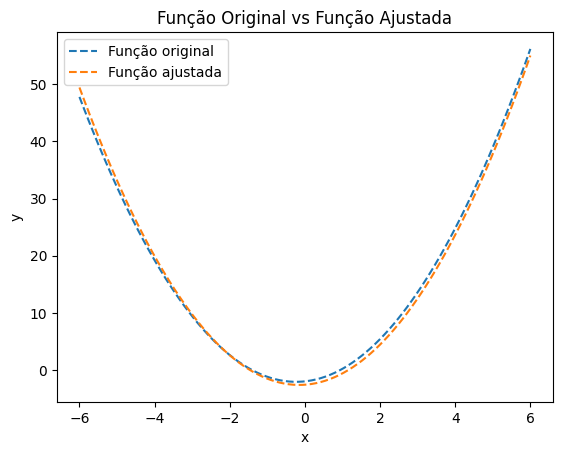

In [76]:
# Define the fitted function
def f_fit(x, theta=theta):
    return theta[0] * x**2 + theta[1] * x + theta[2]

y_fit = f_fit(x, theta)

# Plot the original function and the fitted function
plt.plot(x, y, label='Função original', linestyle='--')
plt.plot(x, y_fit, label='Função ajustada', linestyle='--')
plt.title('Função Original vs Função Ajustada')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [77]:
# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f'Erro máximo: {np.max(np.abs(error)):.2f}')
print(f'Erro médio: {np.mean(np.abs(error)):.2f}')
print(f'Desvio padrão do erro: {np.std(error):.2f}')

Erro máximo: 1.65
Erro médio: 0.82
Desvio padrão do erro: 0.86


In [78]:
# Repeat for N = 1000
x = np.linspace(-6, 6, 1000)
y = f(x)
noise_amp = 0.1 * np.max(np.abs(y))
noise = np.random.uniform(-noise_amp, noise_amp, size=y.shape)
y_measured = y + noise
A = np.vstack([x**2, x, np.ones(len(x))]).T
theta, _, _, _ = np.linalg.lstsq(A, y_measured)
print('Coeficientes estimados para N=1000:')
for i in range(len(theta)):
    print(f'θ_{i} = {theta[i]:.2f}')

Coeficientes estimados para N=1000:
θ_0 = 1.51
θ_1 = 0.68
θ_2 = -2.12


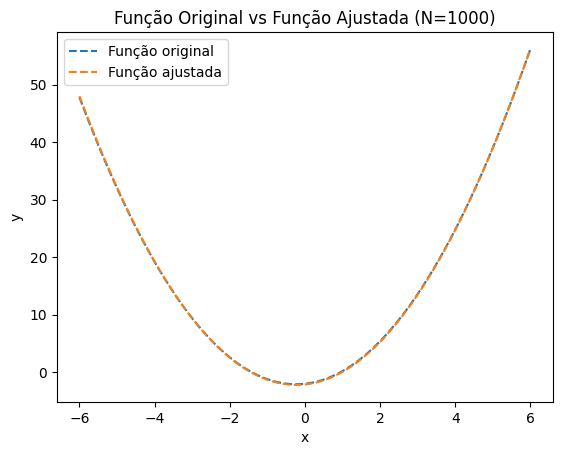

Erro máximo (N=1000): 0.23
Erro médio (N=1000): 0.09
Desvio padrão do erro (N=1000): 0.10


In [79]:
# Compute the fitted values
y_fit = f_fit(x, theta)

# Plot the original function and the fitted function for N=1000
plt.plot(x, y, label='Função original', linestyle='--')
plt.plot(x, y_fit, label='Função ajustada', linestyle='--')
plt.title('Função Original vs Função Ajustada (N=1000)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f'Erro máximo (N=1000): {np.max(np.abs(error)):.2f}')
print(f'Erro médio (N=1000): {np.mean(np.abs(error)):.2f}')
print(f'Desvio padrão do erro (N=1000): {np.std(error):.2f}')

Coeficientes estimados com ruído em x (N=1000):
θ_0 = 1.25
θ_1 = 0.66
θ_2 = 0.58


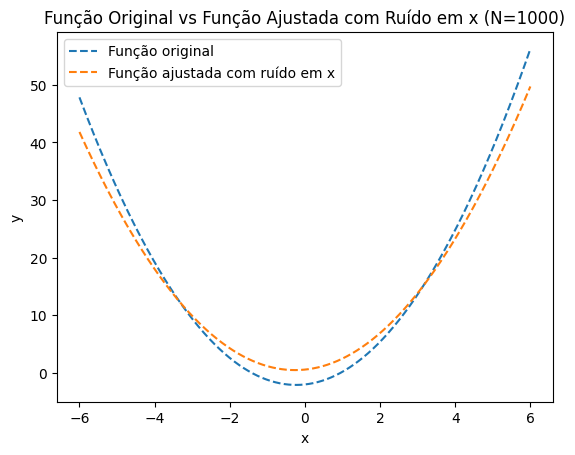

Erro máximo com ruído em x (N=1000): 6.51
Erro médio com ruído em x (N=1000): 2.23
Desvio padrão do erro com ruído em x (N=1000): 2.64


In [80]:
# Now, add noise to the regression variables
noisex_amp = 0.1 * (np.max(x) - np.min(x))
noisex = np.random.uniform(-noisex_amp, noisex_amp, size=x.shape)
x_measured = x + noisex

# Construct the design matrix for quadratic fitting with noisy x
A_noisy = np.vstack([x_measured**2, x_measured, np.ones(len(x_measured))]).T

# Perform least squares fitting to find coefficients with noisy x
theta, _, _, _ = np.linalg.lstsq(A_noisy, y)

# Display the fitted coefficients
print('Coeficientes estimados com ruído em x (N=1000):')
for i in range(len(theta)):
    print(f'θ_{i} = {theta[i]:.2f}')

# Evaluate the fitted function
y_fit = f_fit(x, theta)

# Plot the original function and the fitted function
plt.plot(x, y, label='Função original', linestyle='--')
plt.plot(x, y_fit, label='Função ajustada com ruído em x', linestyle='--')
plt.title('Função Original vs Função Ajustada com Ruído em x (N=1000)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Compute and display maximum, average and standard deviation of the error
error = y - y_fit
print(f'Erro máximo com ruído em x (N=1000): {np.max(np.abs(error)):.2f}')
print(f'Erro médio com ruído em x (N=1000): {np.mean(np.abs(error)):.2f}')
print(f'Desvio padrão do erro com ruído em x (N=1000): {np.std(error):.2f}')

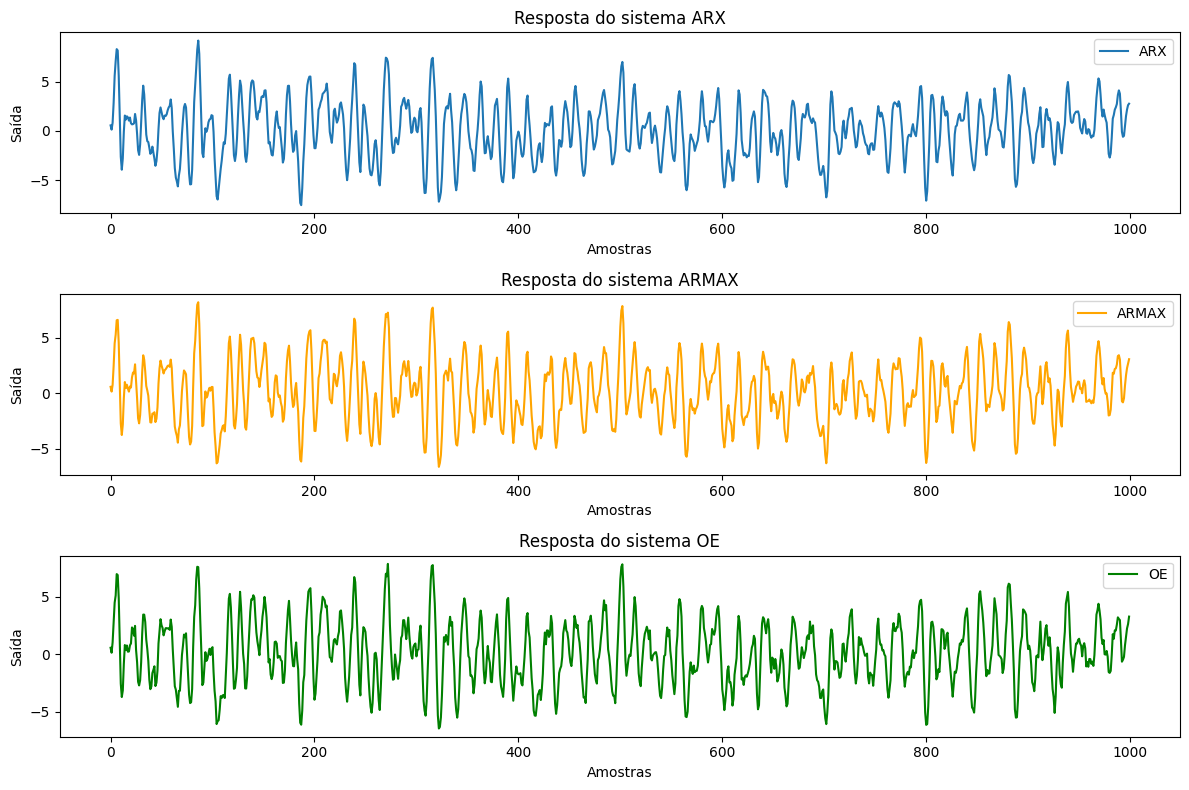

In [81]:
# A(q) = 1 - 1.5q^-1 + 0.7q^-2
# B(q) = 0 + 1.0q^-1 + 0.5q^-2
# C(q) = 1 + 0.8q^-1 + 0.0q^-2

# arx Ay = Bu + e: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k]
#                  y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k]

def arx(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2]
    return 1.5 * y[k-1] - 0.7 * y[k-2] + 1.0 * u[k-1] + 0.5 * u[k-2] + e[k]

# armax Ay = Bu + Ce: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k] - 0.8e[k-1]
#                     y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k] - 0.8e[k-1]

def armax(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1]
    return 1.5 * y[k-1] - 0.7 * y[k-2] + 1.0 * u[k-1] + 0.5 * u[k-2] + e[k] - 0.8 * e[k-1]

# F(q) = A(q)

# oe Fy = Bu + Fe: y[k] - 1.5y[k-1] + 0.7y[k-2] = 1.0u[k-1] + 0.5u[k-2] + e[k] - 1.5e[k-1] + 0.7e[k-2]
#                  y[k] = 1.5y[k-1] - 0.7y[k-2] + 1.0u[k-1] + 0.5u[k-2] + e[k] - 1.5e[k-1] + 0.7e[k-2]

def oe(y, u, e, k):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return (1.5 * y[k-1] - 0.7 * y[k-2] + 1.0 * u[k-1] + 0.5 * u[k-2] +
            e[k] - 1.5 * e[k-1] + 0.7 * e[k-2])

# Set random seed for reproducibility
np.random.seed(0)
N_fit = 1000

# nu = white gaussian with zero mean and variance 0.1
nu = np.random.normal(0, np.sqrt(0.1), N_fit)

# u = white uniform in [-1, 1]
u = np.random.uniform(-1, 1, N_fit)

# Set initial conditions
y_arx, y_armax, y_oe = np.zeros(N_fit), np.zeros(N_fit), np.zeros(N_fit)

# Simulate the systems
for k in range(N_fit):
    y_arx[k] = arx(y_arx, u, nu, k)
    y_armax[k] = armax(y_armax, u, nu, k)
    y_oe[k] = oe(y_oe, u, nu, k)

# Plot the results
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(y_arx, label='ARX')
plt.title('Resposta do sistema ARX')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(y_armax, label='ARMAX', color='orange')
plt.title('Resposta do sistema ARMAX')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(y_oe, label='OE', color='green')
plt.title('Resposta do sistema OE')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()

plt.tight_layout()
plt.show()

# Estimação de ARX

Dado

\begin{equation*}
A(z)y[k] = B(z)u[k] + e[k]
\end{equation*}

com dois atrasos em $A(z)$ e $B(z)$,

\begin{align*}
y[k] + a_1y[k-1] + a_2y[k-2] &= b_1u[k-1] + b_2u[k-2] + e[k] \\
y[k] &= -a_1y[k-1] - a_2y[k-2] + b_1u[k-1] + b_2u[k-2] + e[k]
\end{align*}

Seja

\begin{align*}
Y &=
\begin{bmatrix}
y[2] \\
y[3] \\
y[4] \\
\vdots \\
y[N-1]
\end{bmatrix} \\
\Phi &=
\begin{bmatrix}
y[1] & y[0] & u[1] & u[0] \\
y[2] & y[1] & u[2] & u[1] \\
y[3] & y[2] & u[3] & u[2] \\
\vdots & \vdots & \vdots & \vdots \\
y[N-2] & y[N-3] & u[N-2] & u[N-3]
\end{bmatrix} \\
\theta &=
\begin{bmatrix}
-a_1 \\
-a_2 \\
b_1 \\
b_2
\end{bmatrix} \\
E &=
\begin{bmatrix}
e[2] \\
e[3] \\
e[4] \\
\vdots \\
e[N-1]
\end{bmatrix}
\end{align*},

então

\begin{equation*}
Y = \Phi\theta + E
\end{equation*}

e a estimativa por mínimos quadrados é

\begin{equation*}
\hat{\theta} = (\Phi^T\Phi)^{-1}\Phi^TY
\end{equation*}

ARX Estimated coefficients: A = [ 1.         -1.49435683  0.69953298], B = [0.         0.96895992 0.49752515]


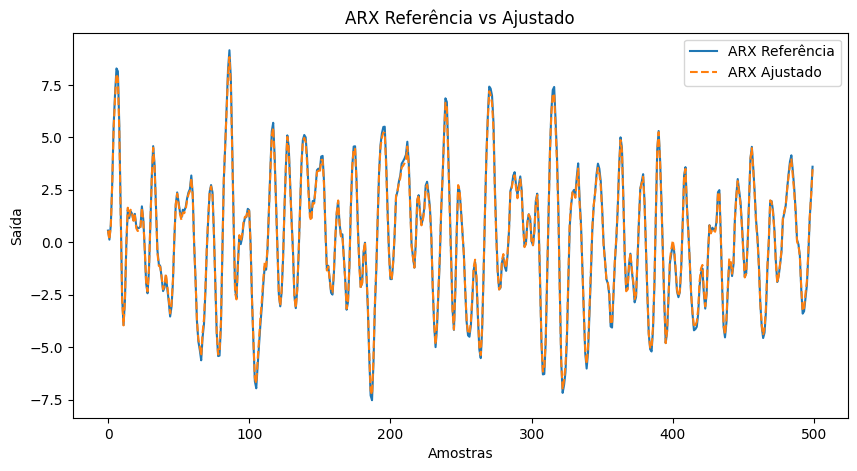

In [82]:
def fit_arx(y: np.ndarray, u: np.ndarray, na: int, nb: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Estimate ARX model parameters using least squares.

    Parameters:
    y : np.ndarray
        Output data.
    u : np.ndarray
        Input data.
    na : int
        Number of poles (order of A).
    nb : int
        Number of zeros (order of B).

    Returns:
    A : np.ndarray
        Estimated coefficients of A polynomial.
    B : np.ndarray
        Estimated coefficients of B polynomial.
    """
    N = len(y)
    assert len(u) == N, "Input and output data must have the same length."

    # Construct the regression matrix
    phi = np.zeros((N - max(na, nb), na + nb))
    for k in range(max(na, nb), N):
        # Fill in the A part (output past values)
        for i in range(1, na + 1):
            phi[k - max(na, nb), i - 1] = -y[k - i]
        # Fill in the B part (input past values)
        for j in range(1, nb + 1):
            phi[k - max(na, nb), na + j - 1] = u[k - j]

    # Corresponding output vector
    y_reg = y[max(na, nb):]

    # Solve the least squares problem
    theta, _, _, _ = np.linalg.lstsq(phi, y_reg, rcond=None)

    # Separate A and B coefficients
    A = np.concatenate(([1], theta[:na]))  # A[0] = 1
    B = np.concatenate(([0], theta[na:]))  # B[0] = 0

    return A, B

arx_A, arx_B = fit_arx(y_arx, u, na=2, nb=2)
print(f'ARX Estimated coefficients: A = {arx_A}, B = {arx_B}')

def arx_fitted(y, u, e, k, A, B):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2]
    return -A[1] * y[k-1] - A[2] * y[k-2] + B[0] * u[k] + B[1] * u[k-1] + B[2] * u[k-2] + e[k]

N_val = 500

y_arx_fit, y_arx_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_arx_fit[k] = arx_fitted(y_arx_fit, u, nu, k, arx_A, arx_B)
    y_arx_ref[k] = arx(y_arx_ref, u, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_arx_ref, label='ARX Referência')
plt.plot(y_arx_fit, label='ARX Ajustado', linestyle='--')
plt.title('ARX Referência vs Ajustado')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()
plt.show()

# Estimação de ARMAX

Dado

\begin{equation*}
A(z)y[k] = B(z)u[k] + C(z)e[k]
\end{equation*}

com dois atrasos em $A(z)$, $B(z)$ e $C(z)$,

\begin{align*}
y[k] + a_1y[k-1] + a_2y[k-2] &= b_1u[k-1] + b_2u[k-2] + e[k] + c_1e[k-1] + c_2e[k-2] \\
y[k] &= -a_1y[k-1] - a_2y[k-2] + b_1u[k-1] + b_2u[k-2] + e[k] + c_1e[k-1] + c_2e[k-2]
\end{align*}

A construção

\begin{equation*}
Y = \Phi\theta
\end{equation*}

com

\begin{align*}
Y &=
\begin{bmatrix}
y[2] \\
y[3] \\
y[4] \\
\vdots \\
y[N-1]
\end{bmatrix} \\
\Phi &=
\begin{bmatrix}
y[1] & y[0] & u[1] & u[0] & e[1] & e[0] \\
y[2] & y[1] & u[2] & u[1] & e[2] & e[1] \\
y[3] & y[2] & u[3] & u[2] & e[3] & e[2] \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
y[N-2] & y[N-3] & u[N-2] & u[N-3] & e[N-2] & e[N-3]
\end{bmatrix} \\
\theta &=
\begin{bmatrix}
-a_1 \\
-a_2 \\
b_1 \\
b_2 \\
c_1 \\
c_2
\end{bmatrix}
\end{align*}

é valida, mas não pode ser usada para estimar $\theta$ por mínimos quadrados, pois $e[k]$ não é conhecido. Neste caso, o método *mínimos quadrados extendido* é uma solução. O algoritmo é:

1. Estime $\theta$ desconsiderando a dinâmica do ruído;
2. Calcule o resíduo $\hat{e}[k] = y[k] - \hat{y}[k]$;
3. Recalcule $\theta$ usando o resíduo no lugar do ruído;
4. Repita os passos 2 e 3 até a convergência.

ARMAX Estimated coefficients: A = [ 1.         -1.42436331  0.63269594], B = [0.         0.94364456 0.59840228], C = [ 1.00000000e+00  1.35022887e-06 -4.74763064e-07], iterations = 6


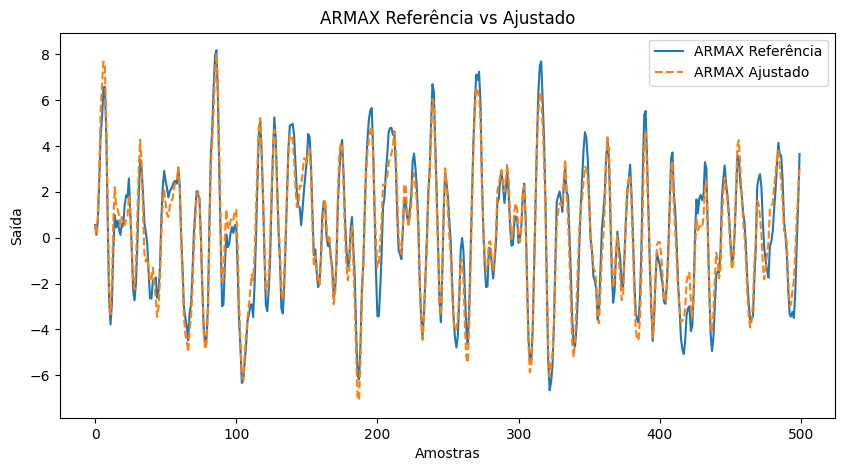

In [84]:
def armax_fitted(y, u, e, k, A, B, C):
    if k < 2:
        return e[k]  # Not enough data for y[k-1], y[k-2], u[k-1], u[k-2], e[k-1], e[k-2]
    return -A[1] * y[k-1] - A[2] * y[k-2] + B[0] * u[k] + B[1] * u[k-1] + B[2] * u[k-2] + C[0] * e[k] + C[1] * e[k-1] + C[2] * e[k-2]

def fit_armax(y: np.ndarray, u: np.ndarray, na: int, nb: int, nc: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    """
    Estimate ARMAX model parameters using extended least squares.

    Parameters:
    y : np.ndarray
        Output data.
    u : np.ndarray
        Input data.
    na : int
        Number of poles (order of A).
    nb : int
        Number of zeros (order of B).
    nc : int
        Order of the noise model (order of C).

    Returns:
    A : np.ndarray
        Estimated coefficients of A polynomial.
    B : np.ndarray
        Estimated coefficients of B polynomial.
    C : np.ndarray
        Estimated coefficients of C polynomial.
    iterations : int
        Number of iterations until convergence.
    """

    N = len(y)
    assert len(u) == N, "Input and output data must have the same length."

    # Step 1: Initial ARX estimation
    A, B = fit_arx(y, u, na, nb)

    # Prepare residuals arrays
    e = y
    e_prev = np.zeros(N)

    # Prepare C
    C = np.zeros(nc + 1)

    # Prepare fitted output
    y_fit = np.zeros(N)

    # Step 4.0: Repeat ...
    for iter in range(int(np.ceil(np.log(N)))):

        # Run the fitted model
        for k in range(N):
            y_fit[k] = armax_fitted(y_fit, u, e, k, A, B, C)
        
        # Step 2: Compute the residuals
        e_prev = e.copy()
        e = y - y_fit

        # Step 4.1: ... until convergence
        if np.allclose(e, e_prev):
            return A, B, C, iter
        
        # Step 3: Re-estimate A, B, C using least squares
        phi = np.zeros((N - max(na, nb, nc), na + nb + nc))
        for k in range(max(na, nb, nc), N):
            # Fill in the A part (output past values)
            for i in range(1, na + 1):
                phi[k - max(na, nb, nc), i - 1] = -y[k - i]
            # Fill in the B part (input past values)
            for j in range(1, nb + 1):
                phi[k - max(na, nb, nc), na + j - 1] = u[k - j]
            # Fill in the C part (error past values)
            for l in range(1, nc + 1):
                phi[k - max(na, nb, nc), na + nb + l - 1] = e[k - l]

        # Corresponding output vector
        y_reg = y[max(na, nb, nc):]

        # Solve the least squares problem
        theta, _, _, _ = np.linalg.lstsq(phi, y_reg)

        # Separate A, B, and C coefficients
        A = np.concatenate(([1], theta[:na]))  # A[0] = 1
        B = np.concatenate(([0], theta[na:na + nb]))  # B[0] = 0
        C = np.concatenate(([1], theta[na + nb:]))  # C[0] = 1

    UserWarning("ARMAX did not converge within the maximum number of iterations.")
    return A, B, C, iter

A, B, C, iter = fit_armax(y_armax, u, na=2, nb=2, nc=2)
print(f'ARMAX Estimated coefficients: A = {A}, B = {B}, C = {C}, iterations = {iter}')

y_armax_fit, y_armax_ref = np.zeros(N_val), np.zeros(N_val)

for k in range(N_val):
    y_armax_fit[k] = armax_fitted(y_armax_fit, u, nu, k, A, B, C)
    y_armax_ref[k] = armax(y_armax_ref, u, nu, k)

plt.figure(figsize=(10, 5))
plt.plot(y_armax_ref, label='ARMAX Referência')
plt.plot(y_armax_fit, label='ARMAX Ajustado', linestyle='--')
plt.title('ARMAX Referência vs Ajustado')
plt.xlabel('Amostras')
plt.ylabel('Saída')
plt.legend()
plt.show()